# Grover's Algorithm — A Complete Teaching Notebook

### From classical search to quantum amplitude amplification

**Instructor notebook** — built with [Qiskit](https://qiskit.org)

---

## Learning Objectives
By the end of this notebook, students will be able to:
1. State the unstructured search problem and explain why classical search needs $O(N)$ queries.
2. Explain how Grover's algorithm achieves $O(\sqrt{N})$ queries using **amplitude amplification**.
3. Construct the two key building blocks of Grover's algorithm: the **Oracle** ($U_f$) and the **Diffuser** ($U_s$).
4. Build, simulate, and visualize a Grover circuit in Qiskit for 2-qubit and 3-qubit search spaces.
5. Understand and visualize the **geometric (2D rotation) interpretation** of Grover's algorithm.
6. Determine the **optimal number of Grover iterations** and see what happens if you over/under-rotate.
7. Compare classical vs. quantum query complexity.

---

## Table of Contents
1. [The Problem: Unstructured Search](#1)
2. [Setup](#2)
3. [Building Block 1 — The Oracle](#3)
4. [Building Block 2 — The Diffuser](#4)
5. [Assembling the Full Grover Circuit (2 qubits)](#5)
6. [Running on a Simulator](#6)
7. [The Geometric Picture](#7)
8. [Scaling Up — 3 Qubits, Multiple Marked States](#8)
9. [Effect of Iteration Count (Over-rotation)](#9)
10. [Classical vs Quantum Complexity](#10)
11. [Summary & Exercises for Students](#11)


<a id="1"></a>
## 1. The Problem: Unstructured Search

Imagine a phonebook with $N$ entries in **random order**, and you want to find the one entry that
matches a phone number. There's no structure to exploit (unlike a sorted list where you could
binary search), so classically:

- **Best classical algorithm:** check entries one by one → on average $N/2$ checks, worst case $N$.
  This is $O(N)$.
- **Grover's quantum algorithm:** $O(\sqrt{N})$ queries to a "black box" oracle that recognizes the answer.

For $N = 2^n$ (i.e., $n$ qubits representing $N$ possible states), Grover's algorithm gives a
**quadratic speedup**: e.g. for $N = 1{,}000{,}000$, classical needs ~500,000 checks on average;
Grover needs only ~1000.

### The core idea
Grover's algorithm doesn't "look" at every item. Instead it:
1. Puts all $N$ basis states into an **equal superposition** (every item is "equally likely").
2. Repeatedly applies two operators that slightly **rotate** the quantum state so that the
   amplitude (and hence probability) of the correct answer grows, while the others shrink.
3. After $\approx \frac{\pi}{4}\sqrt{N}$ repetitions, measuring the qubits gives the correct
   answer with very high probability.

This two-step repeated operation is called **amplitude amplification**, and the two operators are:

| Operator | Symbol | Job |
|---|---|---|
| **Oracle** | $U_f$ | Flips the phase (multiplies by $-1$) of the marked (correct) state(s) |
| **Diffuser** | $U_s$ (inversion about the mean) | Reflects all amplitudes about their average, converting the phase-flip into an amplitude boost |

One full round $G = U_s \, U_f$ is called a **Grover iteration**.


<a id="2"></a>
## 2. Setup

We use **Qiskit** — IBM's open-source quantum computing SDK.


In [1]:
# ============================================================
#  IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, asin, sin, cos, floor

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, array_to_latex
from qiskit_aer import AerSimulator

import qiskit
print("Qiskit version:", qiskit.__version__)

# A consistent color style for our custom diagrams
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11


Qiskit version: 2.1.2


<a id="3"></a>
## 3. Building Block 1 — The Oracle ($U_f$)

The **oracle** is a black-box unitary that "recognizes" the correct answer(s) without revealing
them classically. It does this via a **phase flip**:

$$
U_f |x\rangle = \begin{cases} -|x\rangle & \text{if } x \text{ is the marked (correct) state} \\ \;\;\;|x\rangle & \text{otherwise} \end{cases}
$$

Notice: the oracle does **not** change the probability of measuring any state (since
$|{-1}|^2 = |1|^2 = 1$) — it only flips the *sign* of the amplitude. This is invisible if you
measure right after the oracle! The magic happens in the next step, the diffuser, which turns
this hidden phase-flip into a visible amplitude change.

### Example: marking the state $|11\rangle$ (2 qubits, $N=4$)

A controlled-Z (CZ) gate does exactly this: it flips the phase of $|11\rangle$ and leaves
$|00\rangle, |01\rangle, |10\rangle$ unchanged.


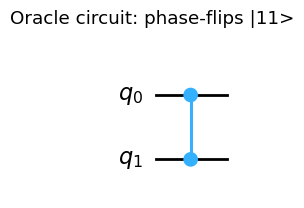

In [2]:
def oracle_mark_11(qc: QuantumCircuit):
    '''Phase-flip the |11> state using a controlled-Z gate.'''
    qc.cz(0, 1)
    return qc

# Visualize the oracle circuit on its own
oracle_demo = QuantumCircuit(2, name="Oracle (marks |11>)")
oracle_mark_11(oracle_demo)
fig = oracle_demo.draw(output='mpl', style={'name': 'iqp'})
fig.suptitle("Oracle circuit: phase-flips |11>", y=1.05)
fig


**Verify it mathematically** — let's print the oracle as a matrix. Notice the $-1$ in the
bottom-right corner, corresponding to the $|11\rangle$ basis state.

In [3]:
oracle_matrix = Operator(oracle_demo).data.real
print("Oracle matrix (should be diag(1, 1, 1, -1)):\n")
print(np.round(oracle_matrix, 2))


Oracle matrix (should be diag(1, 1, 1, -1)):

[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]


<a id="4"></a>
## 4. Building Block 2 — The Diffuser ($U_s$, "Inversion About the Mean")

The diffuser reflects every amplitude about the **average amplitude**. If one amplitude has been
flipped negative by the oracle (while the rest are still positive and roughly equal), this
reflection makes that one amplitude **larger** than all the others.

Mathematically, if $|s\rangle$ is the equal superposition state, the diffuser is:

$$ U_s = 2|s\rangle\langle s| - I $$

**Circuit recipe** (standard construction):
1. Apply $H$ to every qubit
2. Apply $X$ to every qubit
3. Apply a multi-controlled-Z (phase flip on $|11\ldots1\rangle$)
4. Undo: apply $X$ to every qubit
5. Undo: apply $H$ to every qubit

This circuit implements exactly $2|s\rangle\langle s| - I$.


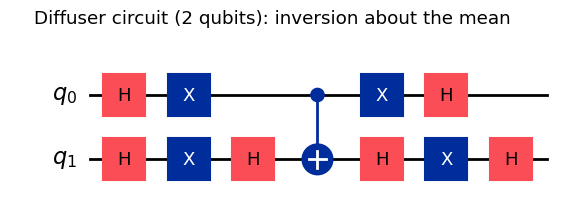

In [4]:
def diffuser(nqubits: int) -> QuantumCircuit:
    '''Standard Grover diffuser (inversion about the mean) for n qubits.'''
    qc = QuantumCircuit(nqubits, name="Diffuser")
    qc.h(range(nqubits))
    qc.x(range(nqubits))

    # Multi-controlled Z on all qubits (phase flip |11...1>)
    qc.h(nqubits - 1)
    qc.mcx(list(range(nqubits - 1)), nqubits - 1)  # multi-controlled X
    qc.h(nqubits - 1)

    qc.x(range(nqubits))
    qc.h(range(nqubits))
    return qc

diffuser_demo = diffuser(2)
fig = diffuser_demo.draw(output='mpl', style={'name': 'iqp'})
fig.suptitle("Diffuser circuit (2 qubits): inversion about the mean", y=1.05)
fig


<a id="5"></a>
## 5. Assembling the Full Grover Circuit (2 qubits, search $|11\rangle$)

**Recipe:**
1. Initialize all qubits with Hadamard gates → equal superposition $|s\rangle$
2. Repeat $r$ times: Oracle → Diffuser
3. Measure

For $N = 4$ ($n=2$), the optimal number of iterations is:
$$ r_{opt} = \left\lfloor \frac{\pi}{4}\sqrt{N} \right\rfloor = \left\lfloor \frac{\pi}{4}\times 2 \right\rfloor = 1 $$

So a **single** Grover iteration should already boost $|11\rangle$'s probability close to 1.


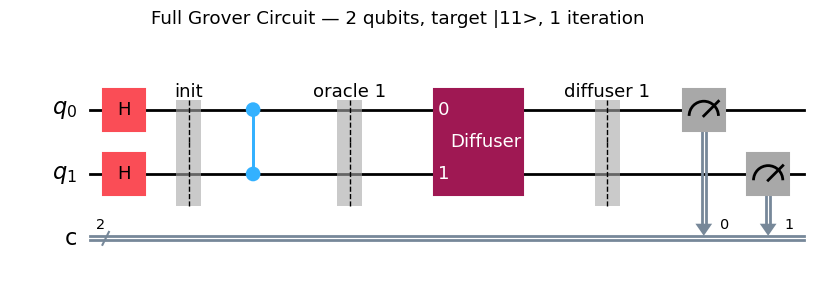

In [5]:
def grover_circuit(n_qubits: int, oracle_fn, iterations: int, measure=True) -> QuantumCircuit:
    '''Builds a full Grover circuit: superposition + (oracle+diffuser) x iterations.'''
    qc = QuantumCircuit(n_qubits, n_qubits)

    # Step 1: equal superposition
    qc.h(range(n_qubits))
    qc.barrier(label="init")

    # Step 2: Grover iterations
    for i in range(iterations):
        oracle_fn(qc)
        qc.barrier(label=f"oracle {i+1}")
        qc.append(diffuser(n_qubits).to_gate(label="Diffuser"), range(n_qubits))
        qc.barrier(label=f"diffuser {i+1}")

    if measure:
        qc.measure(range(n_qubits), range(n_qubits))
    return qc

grover_2q = grover_circuit(2, oracle_mark_11, iterations=1)
fig = grover_2q.draw(output='mpl', style={'name': 'iqp'}, fold=-1)
fig.suptitle("Full Grover Circuit — 2 qubits, target |11>, 1 iteration", y=1.05)
fig


<a id="6"></a>
## 6. Running on a Simulator

Let's simulate the circuit above and look at the measurement histogram. If our reasoning is
correct, $|11\rangle$ should dominate.


Measurement counts: {'11': 4096}


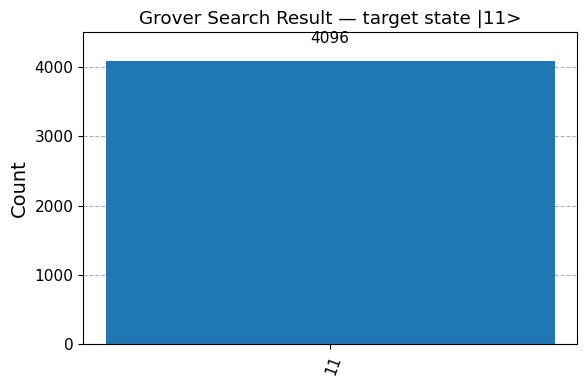

In [6]:
simulator = AerSimulator()
compiled = transpile(grover_2q, simulator)
result = simulator.run(compiled, shots=4096).result()
counts = result.get_counts()

print("Measurement counts:", counts)
fig = plot_histogram(counts, title="Grover Search Result — target state |11>", figsize=(6, 4))
fig


**Discussion for students:** With just **one** application of the Oracle + Diffuser, we
find `11` with near-certainty (~100% for the ideal noiseless case) even though a classical
search would need up to 4 guesses (or 2 on average) to find it in a 4-item space. For $N=4$ this
speedup is modest, but it grows as $\sqrt{N}$ vs $N$ for larger search spaces, as we'll see.

<a id="7"></a>
## 7. The Geometric Picture

This is the most important intuition to give students. Let:
- $|\beta\rangle$ = equal superposition of *marked* states
- $|\alpha\rangle$ = equal superposition of *unmarked* states

The initial state $|s\rangle = H^{\otimes n}|0\rangle$ can be written as a vector in the 2D
plane spanned by $|\alpha\rangle$ and $|\beta\rangle$, at angle $\theta/2$ from $|\alpha\rangle$,
where $\sin(\theta/2) = \sqrt{M/N}$ ($M$ = number of marked states).

**Each Grover iteration rotates the state vector by angle $\theta$ towards $|\beta\rangle$**
(the "good" subspace). This is why:
- The Oracle = a **reflection** about $|\alpha\rangle$
- The Diffuser = a **reflection** about $|s\rangle$
- Two reflections = a **rotation** by $2\times(\text{angle between the two mirror lines})=\theta$

Let's draw this rotation for our 2-qubit example ($N=4$, $M=1$).


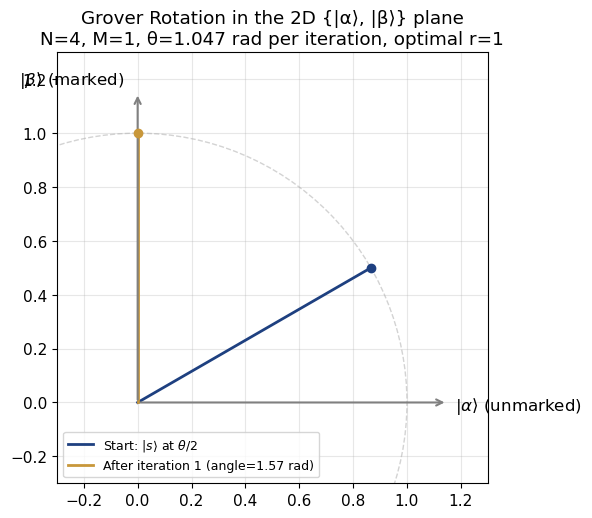

In [7]:
# ============================================================
#  Geometric visualization of Grover's algorithm as rotation
# ============================================================
N, M = 4, 1
theta = 2 * asin(sqrt(M / N))     # full rotation angle per iteration
theta_half = theta / 2

fig, ax = plt.subplots(figsize=(6, 6))

# Draw axes: alpha (unmarked) horizontal, beta (marked) vertical
ax.annotate('', xy=(1.15, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
ax.annotate('', xy=(0, 1.15), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
ax.text(1.18, -0.03, r'$|\alpha\rangle$ (unmarked)', fontsize=12)
ax.text(-0.05, 1.18, r'$|\beta\rangle$ (marked)', fontsize=12, ha='right')

colors = ['#1E4080', '#C8973A', '#1A2744', '#8B0000']

r_opt = floor(pi / (2 * theta))
angle = theta_half
ax.plot([0, cos(a:=theta_half)], [0, sin(a)], color=colors[0], lw=2,
        label=r'Start: $|s\rangle$ at $\theta/2$')
ax.scatter([cos(theta_half)], [sin(theta_half)], color=colors[0], zorder=5)

current_angle = theta_half
for i in range(1, r_opt + 1):
    current_angle += theta
    x, y = cos(current_angle), sin(current_angle)
    ax.plot([0, x], [0, y], color=colors[i % len(colors)], lw=2,
            label=f'After iteration {i} (angle={current_angle:.2f} rad)')
    ax.scatter([x], [y], color=colors[i % len(colors)], zorder=5)

# unit circle for reference
circ = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='lightgray')
ax.add_patch(circ)

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_aspect('equal')
ax.set_title(f"Grover Rotation in the 2D {{|α⟩, |β⟩}} plane\n"
             f"N={N}, M={M}, θ={theta:.3f} rad per iteration, optimal r={r_opt}")
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Notice how each iteration rotates the state vector by a **fixed angle $\theta$** closer
to $|\beta\rangle$ (the marked-state axis). After the optimal number of iterations
$r_{opt}=\lfloor \pi/(2\theta) \rfloor$ (equivalently $\approx \frac{\pi}{4}\sqrt{N/M}$), the
state vector is closest to $|\beta\rangle$, maximizing the probability of measuring a marked
state. **If you keep rotating past this point, you overshoot** — we'll demonstrate that in
Section 9.

<a id="8"></a>
## 8. Scaling Up — 3 Qubits, Multiple Marked States

Let's generalize to $n=3$ qubits ($N=8$ possible states) and mark **two** states, say
$|101\rangle$ and $|110\rangle$ ($M=2$).

Optimal iterations:
$$ r_{opt} = \left\lfloor \frac{\pi}{4}\sqrt{N/M} \right\rfloor = \left\lfloor \frac{\pi}{4}\sqrt{8/2} \right\rfloor = \left\lfloor \frac{\pi}{4}\times 2 \right\rfloor = 1 $$


N=8, M=2, optimal iterations r_opt=1


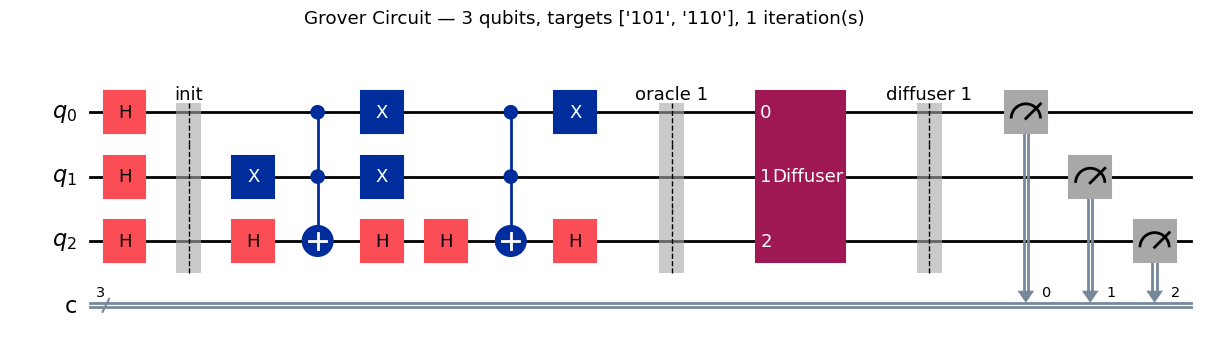

In [8]:
def oracle_mark_multiple(qc: QuantumCircuit, marked_states: list[str]):
    '''
    Phase-flip an arbitrary set of computational basis states.
    marked_states: list of bitstrings, e.g. ['101', '110'] (little/big-endian handled below)
    '''
    n = qc.num_qubits
    for state in marked_states:
        # Qiskit uses little-endian: qubit 0 is the rightmost bit of the bitstring.
        bits = state[::-1]

        # Flip 0-bits to 1 so we can use a multi-controlled-Z on all-ones pattern
        zero_positions = [i for i, b in enumerate(bits) if b == '0']
        qc.x(zero_positions)

        # Multi-controlled Z across all n qubits
        qc.h(n - 1)
        qc.mcx(list(range(n - 1)), n - 1)
        qc.h(n - 1)

        # Undo the X flips
        qc.x(zero_positions)
    return qc


marked = ['101', '110']
n_qubits = 3
N, M = 2**n_qubits, len(marked)
r_opt = floor((pi / 4) * sqrt(N / M))
print(f"N={N}, M={M}, optimal iterations r_opt={r_opt}")

grover_3q = grover_circuit(
    n_qubits,
    lambda qc: oracle_mark_multiple(qc, marked),
    iterations=r_opt
)

fig = grover_3q.draw(output='mpl', style={'name': 'iqp'}, fold=-1)
fig.suptitle(f"Grover Circuit — 3 qubits, targets {marked}, {r_opt} iteration(s)", y=1.02)
fig


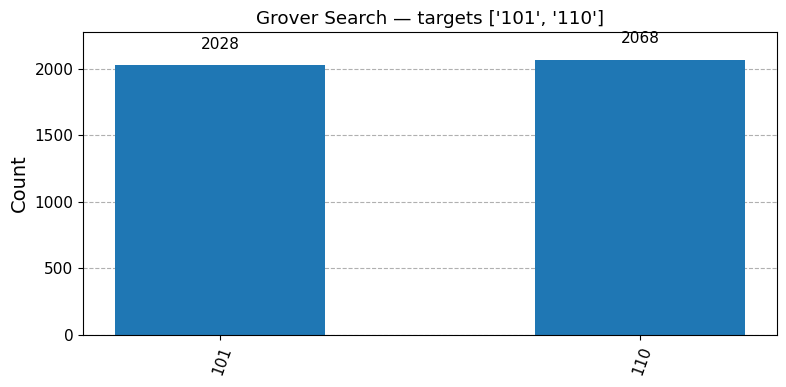

In [9]:
compiled3 = transpile(grover_3q, simulator)
result3 = simulator.run(compiled3, shots=4096).result()
counts3 = result3.get_counts()

fig = plot_histogram(counts3, title=f"Grover Search — targets {marked}", figsize=(8, 4))
fig


Both `101` and `110` should now dominate the histogram — Grover's algorithm
simultaneously amplified **both** marked states because the oracle marks the entire subspace
$\{|101\rangle, |110\rangle\}$, and the diffuser rotates the state towards *that whole subspace*.

<a id="9"></a>
## 9. Effect of Iteration Count — Why "Optimal" Matters

What happens if we apply **too many** or **too few** iterations? Since each iteration is a
fixed-angle rotation, going past the optimal point rotates *past* $|\beta\rangle$ and probability
starts to **decrease** again — an important and often-surprising lesson for students!

Let's sweep the iteration count from 0 to 10 for our single-marked-state, 3-qubit example
(target: `101`) and plot success probability vs. iterations.


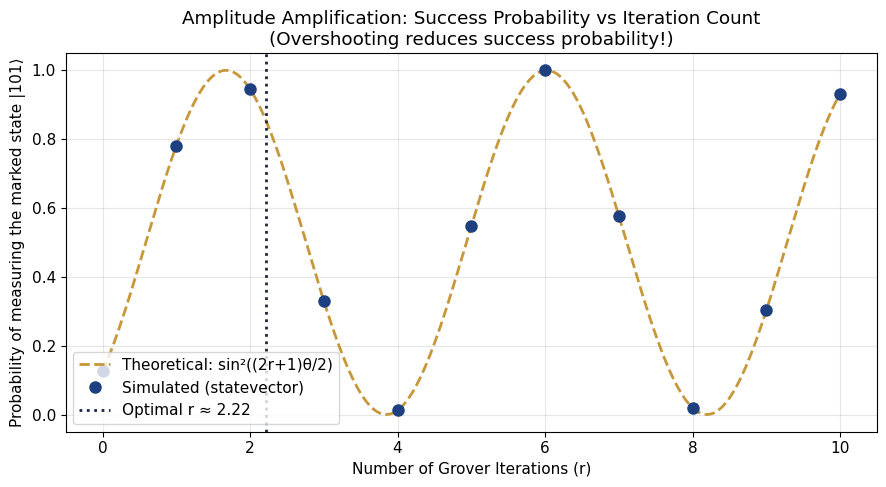

Optimal r = 2.221 -> round to r = 2
Success probabilities per iteration: [np.float64(0.125), np.float64(0.781), np.float64(0.945), np.float64(0.33), np.float64(0.012), np.float64(0.548), np.float64(1.0), np.float64(0.577), np.float64(0.019), np.float64(0.303), np.float64(0.931)]


In [10]:
marked_single = ['101']
N = 2**3
M = 1
theta = 2 * asin(sqrt(M / N))

iter_range = range(0, 11)
success_probs = []

for r in iter_range:
    qc = grover_circuit(3, lambda qc, m=marked_single: oracle_mark_multiple(qc, m),
                         iterations=r, measure=False)
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities_dict()
    p_success = probs.get('101', 0.0)
    success_probs.append(p_success)

# Theoretical curve: P(r) = sin^2((2r+1) * theta/2)
r_fine = np.linspace(0, 10, 300)
theory = np.sin((2 * r_fine + 1) * theta / 2) ** 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(r_fine, theory, '--', color='#C8973A', lw=2, label='Theoretical: sin²((2r+1)θ/2)')
ax.plot(list(iter_range), success_probs, 'o', color='#1E4080', markersize=8,
        label='Simulated (statevector)')
ax.axvline(x=(pi/4)*sqrt(N/M), color='#1A2744', linestyle=':', lw=2,
           label=f'Optimal r ≈ {(pi/4)*sqrt(N/M):.2f}')

ax.set_xlabel("Number of Grover Iterations (r)")
ax.set_ylabel("Probability of measuring the marked state |101⟩")
ax.set_title("Amplitude Amplification: Success Probability vs Iteration Count\n"
             "(Overshooting reduces success probability!)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal r = {(pi/4)*sqrt(N/M):.3f} -> round to r = {round((pi/4)*sqrt(N/M))}")
print("Success probabilities per iteration:", [round(p, 3) for p in success_probs])


**Key teaching point:** the probability oscillates like $\sin^2\!\big((2r{+}1)\theta/2\big)$.
Too few iterations under-rotates (low success probability); too many **over-rotates past the
target** and probability drops again. This periodic behavior is one of the most important and
counter-intuitive aspects of Grover's algorithm for students to internalize — **more iterations
is not always better!**

<a id="10"></a>
## 10. Classical vs. Quantum Query Complexity

Let's directly compare the number of oracle queries needed by classical brute-force search
(on average, $N/2$) versus Grover's algorithm ($\approx \frac{\pi}{4}\sqrt{N}$), across a range
of database sizes $N = 2^n$.


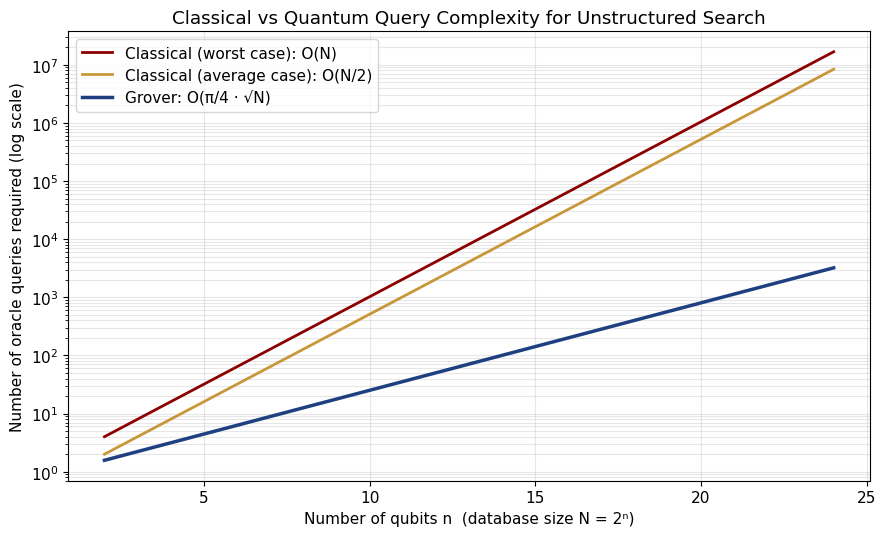

n=10  N=     1,024   classical avg ≈        512 queries   Grover ≈     25 queries   speedup ≈ 20.4x
n=20  N= 1,048,576   classical avg ≈    524,288 queries   Grover ≈    804 queries   speedup ≈ 651.9x


In [11]:
ns = np.arange(2, 25)              # n = number of qubits
Ns = 2 ** ns                        # N = database size
classical_avg = Ns / 2
classical_worst = Ns
grover_queries = (pi / 4) * np.sqrt(Ns)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(ns, classical_worst, color='#8B0000', lw=2, label='Classical (worst case): O(N)')
ax.plot(ns, classical_avg, color='#C8973A', lw=2, label='Classical (average case): O(N/2)')
ax.plot(ns, grover_queries, color='#1E4080', lw=2.5, label='Grover: O(π/4 · √N)')

ax.set_yscale('log')
ax.set_xlabel("Number of qubits n  (database size N = 2ⁿ)")
ax.set_ylabel("Number of oracle queries required (log scale)")
ax.set_title("Classical vs Quantum Query Complexity for Unstructured Search")
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Concrete example for the class
for n_example in [10, 20]:
    N_example = 2 ** n_example
    print(f"n={n_example:2d}  N={N_example:>10,}   "
          f"classical avg ≈ {N_example//2:>10,} queries   "
          f"Grover ≈ {round((pi/4)*sqrt(N_example)):>6,} queries   "
          f"speedup ≈ {(N_example/2)/((pi/4)*sqrt(N_example)):.1f}x")


**Discussion:** at $n=20$ qubits ($N\approx10^6$), classical search needs ~500,000
queries on average while Grover needs roughly 800 — over a 600x speedup. This gap **widens** as
$N$ grows, which is exactly the quadratic speedup $O(\sqrt N)$ vs $O(N)$ we set out to
demonstrate.

<a id="11"></a>
## 11. Summary

| Concept | Key takeaway |
|---|---|
| **Problem** | Find a marked item among $N$ unstructured items |
| **Classical complexity** | $O(N)$ |
| **Quantum complexity (Grover)** | $O(\sqrt{N})$ — a **quadratic** speedup |
| **Oracle $U_f$** | Flips the phase of marked state(s); doesn't change measurement probabilities by itself |
| **Diffuser $U_s$** | Inversion about the mean; turns the phase-flip into an amplitude boost |
| **Grover iteration** | $G = U_s U_f$ = one full rotation step of angle $\theta$ towards the "good" subspace |
| **Optimal iterations** | $r_{opt} \approx \frac{\pi}{4}\sqrt{N/M}$ — overshooting **reduces** success probability |
| **Geometric picture** | State vector rotates in a 2D plane spanned by "marked" and "unmarked" superpositions |

---

## Exercises for Students

1. **Change the target.** Modify `oracle_mark_11` to instead mark $|00\rangle$ or $|01\rangle$.
   Verify the histogram in Section 6 changes accordingly.
2. **Derive the rotation angle.** Show that $\sin(\theta/2) = \sqrt{M/N}$ starting from the
   inner product $\langle s | \beta \rangle$.
3. **3-qubit single marked state.** Using the framework in Section 8, mark only `111` with
   $n=3$. Compute $r_{opt}$ by hand first, then verify with code.
4. **Break it.** In Section 9, run 15–20 iterations instead of 10. Explain what pattern you see
   and why (hint: it's periodic).
5. **4 qubits, 4 marked states.** Set $n=4$ ($N=16$), and mark any 4 basis states. Compute
   $r_{opt}$ and confirm your circuit finds them with high probability.
6. **(Challenge) Unknown $M$.** In real applications we often don't know how many solutions
   exist ($M$). Research the **Grover algorithm with unknown number of solutions**
   (Boyer–Brassard–Høyer–Tapp, 1998) and summarize the modification in 3–4 sentences.
7. **(Challenge) Real hardware.** Replace `AerSimulator()` with an IBM Quantum backend
   (`qiskit-ibm-runtime`) and discuss how noise affects the histogram compared to the ideal
   simulation above.

---

*Notebook built for classroom use — feel free to adapt the color scheme, oracle targets, and
qubit counts to fit your lecture.*
